In [1]:
import pandas as pd
import requests
import plotly.express as px

In [2]:
url = "https://services.swpc.noaa.gov/products/solar-wind/plasma-7-day.json"

response = requests.get(url)

In [3]:
print("Status Code:", response.status_code)

Status Code: 200


In [4]:
data = response.json()

In [5]:
print(type(data))

<class 'list'>


In [6]:
print(data[0])  # Print the first entry in the data list

['time_tag', 'density', 'speed', 'temperature']


In [7]:
print("Rows:", len(data))
print("Header:", data[0])
print("First Record:", data[1])

Rows: 9875
Header: ['time_tag', 'density', 'speed', 'temperature']
First Record: ['2026-06-17 05:47:00.000', '7.99', '422.7', '55126']


In [8]:
headers = data[0]
rows = data[1:]

In [9]:
df = pd.DataFrame(rows, columns=headers)

In [10]:
df["density"] = pd.to_numeric(df["density"])
df["speed"] = pd.to_numeric(df["speed"])
df["temperature"] = pd.to_numeric(df["temperature"])

df["time_tag"] = pd.to_datetime(df["time_tag"])

In [11]:
df.head()

,time_tag,density,speed,temperature
0,2026-06-17 05:47:00,7.99,422.7,55126
1,2026-06-17 05:48:00,7.94,423.3,55622
2,2026-06-17 05:49:00,7.90,421.8,58722
3,2026-06-17 05:50:00,8.34,420.5,47163
4,2026-06-17 05:51:00,9.00,421.4,45919


## Solar Wind Parameters

| Parameter | Range | Status | Typical Meaning |
|------------|---------|---------|------------------|
| Speed | 300–400 km/s | Slow | Quiet solar wind |
| Speed | 400–500 km/s | Average | Normal conditions |
| Speed | 600–800 km/s | Fast | Increased geomagnetic potential |
| Speed | >1000 km/s | Extreme | Major solar disturbance possible |
| Density | 1–5 p/cm³ | Low | Weak solar wind pressure |
| Density | 5–10 p/cm³ | Average | Normal conditions |
| Density | 20–50 p/cm³ | High | Strong compression of magnetosphere |
| Density | >100 p/cm³ | Extreme | CME/shock often present |
| Temperature | 100k–300k K | Average | Typical solar wind |
| Temperature | 300k–700k K | Warm | Faster solar wind streams |
| Temperature | 700k–1.5M K | Hot | Energetic plasma |
| Temperature | >1.5M K | Very Hot | Disturbed solar wind/CME conditions |

In [12]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9874 entries, 0 to 9873
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time_tag     9874 non-null   datetime64[us]
 1   density      9874 non-null   float64       
 2   speed        9874 non-null   float64       
 3   temperature  9874 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(1)
memory usage: 308.7 KB
None


In [13]:
print(df.describe())


                         time_tag      density        speed    temperature
count                        9874  9874.000000  9874.000000    9874.000000
mean   2026-06-20 18:18:13.587198     6.208257   387.999706   82680.058943
min           2026-06-17 05:47:00     0.120000   322.200000    7019.000000
25%           2026-06-19 00:38:15     4.540000   365.400000   53033.000000
50%           2026-06-20 18:23:30     5.960000   379.100000   72744.500000
75%           2026-06-22 12:12:45     7.340000   405.400000  102931.000000
max           2026-06-24 05:43:00    19.390000   508.600000  370029.000000
std                           NaN     2.343075    34.432727   46020.016037


In [14]:
print(df["density"].describe())
print(df["speed"].describe())
print(df["temperature"].describe())

count    9874.000000
mean        6.208257
std         2.343075
min         0.120000
25%         4.540000
50%         5.960000
75%         7.340000
max        19.390000
Name: density, dtype: float64
count    9874.000000
mean      387.999706
std        34.432727
min       322.200000
25%       365.400000
50%       379.100000
75%       405.400000
max       508.600000
Name: speed, dtype: float64
count      9874.000000
mean      82680.058943
std       46020.016037
min        7019.000000
25%       53033.000000
50%       72744.500000
75%      102931.000000
max      370029.000000
Name: temperature, dtype: float64


In [15]:
fig = px.line(
    df,
    x="time_tag",
    y = "density",
    title = "Solar Wind Density - Last 7 Days"
)

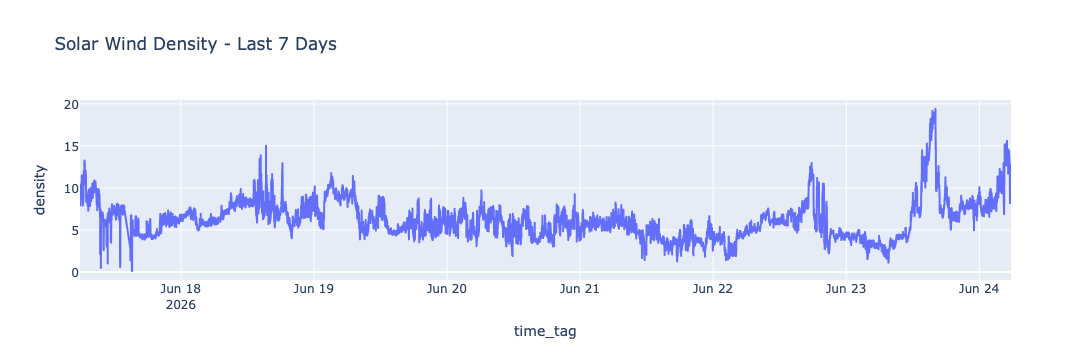

In [16]:
fig

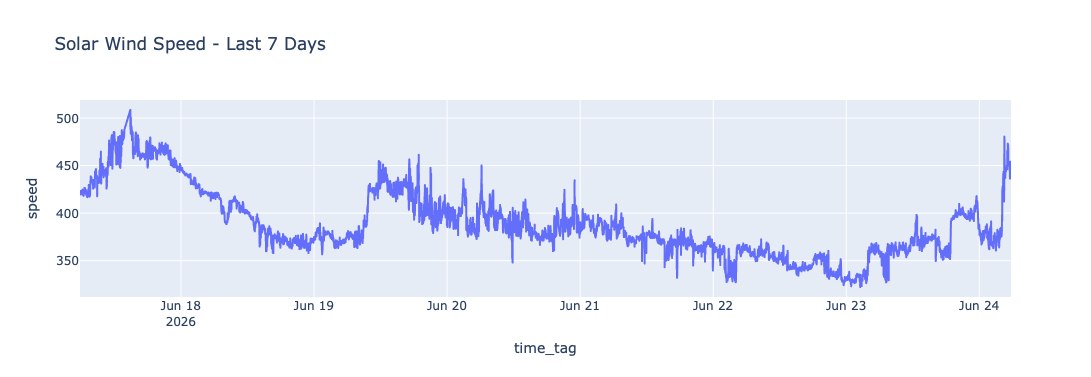

In [17]:
fig = px.line(
    df,
    x="time_tag",
    y = "speed",
    title = "Solar Wind Speed - Last 7 Days"
)

fig

In [18]:
print(df.loc[df["speed"].idxmax()])
print(df.loc[df["density"].idxmax()])
print(df.loc[df["temperature"].idxmax()])

time_tag       2026-06-17 14:52:00
density                       2.78
speed                        508.6
temperature                   9703
Name: 464, dtype: object
time_tag       2026-06-23 16:05:00
density                      19.39
speed                        378.8
temperature                  42104
Name: 9055, dtype: object
time_tag       2026-06-17 14:58:00
density                       6.75
speed                        500.2
temperature                 370029
Name: 470, dtype: object


In [19]:
print(
    df[["density", "speed", "temperature"]].corr()
)

              density     speed  temperature
density      1.000000  0.180082     0.063306
speed        0.180082  1.000000     0.704484
temperature  0.063306  0.704484     1.000000


1. +1.0  → Strong Positive Correlation
2. 0.5  → Moderate Positive Correlation
3. 0.0  → No Correlation
4. -0.5  → Moderate Negative Correlation
5. -1.0  → Strong Negative Correlation

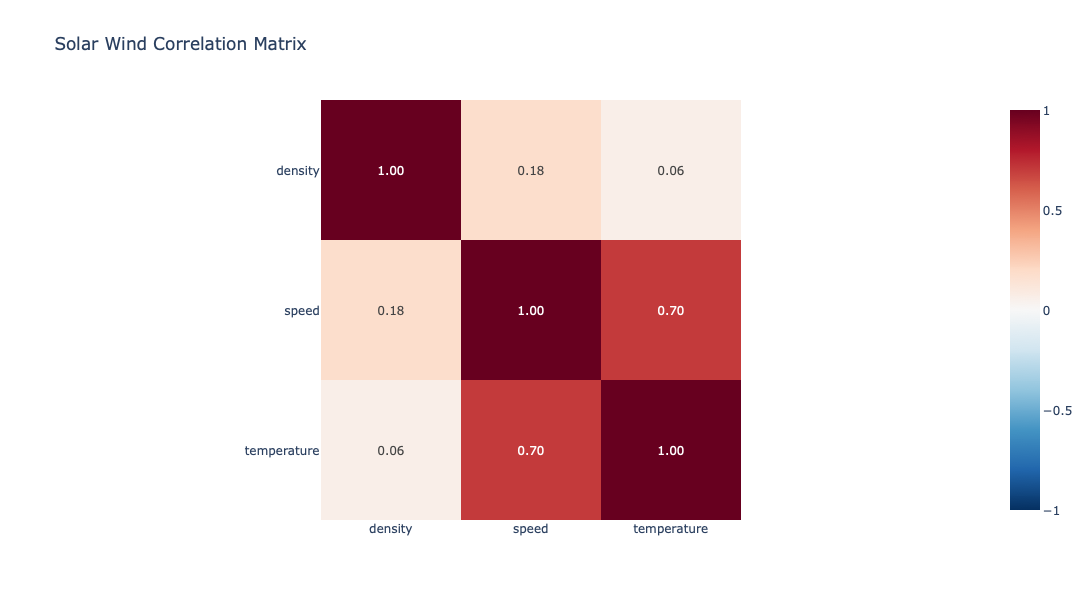

In [20]:
import plotly.express as px

corr_matrix = df[["density", "speed", "temperature"]].corr()

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Solar Wind Correlation Matrix"
)

fig.update_layout(
    width=700,
    height=600
)

fig.show()

**Intrepretations and Physics from the Correalation Matrix**
1. Fast Solar Wind -> Particles Carry more Kinetic Energy -> Higher measured temperature
2. With Density and Speed there is almost no meaningful relationship
   1. We can Have High Density + Low Speed
   2. High Density + High Speed
   3. Low Density + Low Speed
   4. Low Density + High Speed
3. Density and Temperature have little to weak relationship

**Density is often Controlled by**

1. CME fronts
2. Shock Waves
3. Compression Regions
4. Coronal Structures
5. Local Solar Wind Stream interactions

Therefore Density can spike dramatically without speed increasing 


1. Solar wind speed and temperature exhibit a consistent
positive correlation (r ≈ 0.5–0.7), indicating that faster
solar wind streams are generally associated with hotter plasma.

2. Solar wind density shows little relationship with speed,
with correlations near zero and changing sign between
observation periods.

3. Density also exhibits weak and inconsistent correlation
with temperature, suggesting it is influenced by separate
solar wind structures and compression effects.

4. Among the three parameters, speed and temperature form
the strongest and most physically meaningful relationship
in the dataset.